In [2]:
import matplotlib.pyplot as plt 
import pandas as pd
import numpy as np 
import seaborn as sns

In [3]:
np.random.seed(52)
jan_sales=pd.DataFrame({
    'order_id':np.arange(1,501),
    'customer_id':np.random.randint(1,201,500),
    'category':np.random.choice(['Elec', 'Cloths', 'Home', 'Sports'], 500),
    'amount':np.random.randint(200, 10000, 500),
    'month':'January'
})

In [4]:
feb_sales = pd.DataFrame({
    'order_id': np.arange(501, 1001),
    'customer_id': np.random.randint(1, 201, 500),
    'category': np.random.choice(['Electronics','Clothing','Home','Sports'], 500),
    'amount': np.random.randint(200, 10000, 500),
    'month': 'February'
})

In [5]:
sales=pd.concat([jan_sales, feb_sales], ignore_index=True)

In [6]:
sales

,order_id,customer_id,category,amount,month
0,1,157,Cloths,4697,January
1,2,12,Sports,1416,January
2,3,14,Cloths,5903,January
3,4,152,Home,5381,January
4,5,87,Sports,6633,January
...,...,...,...,...,...
995,996,186,Sports,3994,February
996,997,131,Electronics,1456,February
997,998,67,Clothing,7834,February
998,999,185,Home,3400,February


In [7]:
sales.to_csv('Rough.csv')

In [8]:
sales.loc[np.random.choice(sales.index, 30), 'amount']=np.nan

In [9]:
sales.to_csv('Added_missing_values.csv')

In [10]:
sales=pd.concat([sales, sales.iloc[:20]], ignore_index=True)

In [11]:
sales.to_csv('Added Dupicate values.csv')

In [15]:
sales.isnull().sum()

order_id        0
customer_id     0
category        0
amount         29
month           0
dtype: int64

In [16]:
sales['amount']=sales['amount'].fillna(sales['amount'].median())

In [24]:
sales.isnull().sum() #Verified

order_id       0
customer_id    0
category       0
amount         0
month          0
dtype: int64

In [26]:
sales.duplicated().sum()

np.int64(20)

In [27]:
sales=sales.drop_duplicates()

In [29]:
sales.duplicated().sum() # Verified

np.int64(0)

<Axes: ylabel='amount'>

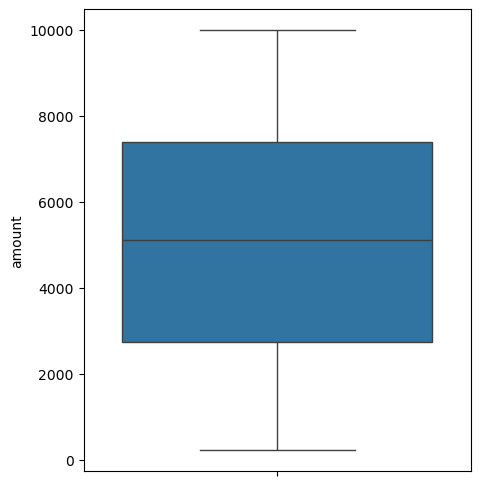

In [37]:
plt.figure(figsize=(5,6))
sns.boxplot(
    y=sales['amount']
)

In [52]:
Q1=sales['amount'].quantile(0.25)
Q3=sales['amount'].quantile(0.75)
IQR=Q3-Q1
Q1, IQR

(np.float64(2746.75), np.float64(4645.25))

In [47]:
lower_range=Q1-1.5*IQR
upper_range=Q3+1.5*IQR

In [62]:
sales_clean=sales[(sales['amount']<=upper_range) & (sales['amount']>=lower_range)]

In [67]:
sales_clean.nlargest(10, columns='amount')

,order_id,customer_id,category,amount,month
958,959,56,Sports,9987.0,February
507,508,145,Clothing,9977.0,February
472,473,120,Sports,9964.0,January
222,223,171,Elec,9941.0,January
607,608,190,Clothing,9932.0,February
652,653,31,Sports,9932.0,February
987,988,132,Clothing,9920.0,February
155,156,74,Home,9918.0,January
641,642,200,Clothing,9912.0,February
485,486,32,Cloths,9909.0,January


In [73]:
sales_clean.groupby('category').apply(lambda x: x.nlargest(10, 'amount'))

C:\Users\anshp\AppData\Local\Temp\ipykernel_2640\2662427499.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sales_clean.groupby('category').apply(lambda x: x.nlargest(10, 'amount'))


order_id  customer_id     category  amount     month
category                                                             
Clothing    507       508          145     Clothing  9977.0  February
            607       608          190     Clothing  9932.0  February
            987       988          132     Clothing  9920.0  February
            641       642          200     Clothing  9912.0  February
            741       742           70     Clothing  9793.0  February
            505       506          103     Clothing  9738.0  February
            914       915           89     Clothing  9688.0  February
            606       607           95     Clothing  9673.0  February
            538       539           67     Clothing  9659.0  February
            794       795          152     Clothing  9609.0  February
Cloths      485       486           32       Cloths  9909.0   January
            314       315          192       Cloths  9823.0   January
            455       456          144       Cloths  9810.0   January
            140       141          106       Cloths  9639.0   January
            257       258           74       Cloths  9351.0   January
            387       388          164       Cloths  9351.0   January
            151       152          126       Cloths  9302.0   January
            136       137           86       Cloths  9279.0   January
            118       119          145       Cloths  9162.0   January
            189       190           70       Cloths  8937.0   January
Elec        222       223          171         Elec  9941.0   January
            401       402           46         Elec  9770.0   January
            232       233          117         Elec  9593.0   January
            30         31          172         Elec  9555.0   January
            152       153           46         Elec  9421.0   January
            297       298          100         Elec  9411.0   January
            168       169          193         Elec  9404.0   January
            138       139           37         Elec  9358.0   January
            267       268           22         Elec  9356.0   January
            309       310          141         Elec  9334.0   January
Electronics 881       882           89  Electronics  9862.0  February
            565       566          134  Electronics  9844.0  February
            892       893           46  Electronics  9806.0  February
            716       717          179  Electronics  9688.0  February
            853       854          105  Electronics  9652.0  February
            972       973           65  Electronics  9549.0  February
            514       515            3  Electronics  9505.0  February
            521       522          135  Electronics  9279.0  February
            862       863          179  Electronics  9224.0  February
            684       685          191  Electronics  9135.0  February
Home        155       156           74         Home  9918.0   January
            84         85          183         Home  9853.0   January
            774       775           40         Home  9817.0  February
            542       543          199         Home  9815.0  February
            370       371           79         Home  9782.0   January
            381       382          189         Home  9742.0   January
            739       740          126         Home  9677.0  February
            799       800           45         Home  9656.0  February
            694       695           58         Home  9635.0  February
            160       161          122         Home  9623.0   January
Sports      958       959           56       Sports  9987.0  February
            472       473          120       Sports  9964.0   January
            652       653           31       Sports  9932.0  February
            962       963          156       Sports  9889.0  February
            255       256          133       Sports  9853.0   January
            422       423  

In [86]:
pivot_table=pd.pivot_table(
    sales_clean,
    index='month',
    columns='category',
    values='amount',
    aggfunc='sum'
)

In [87]:
pivot_table

category,Clothing,Cloths,Elec,Electronics,Home,Sports
month,,,,,,
February,634913.0,NaN,NaN,624913.0,623822.0,701441.0
January,NaN,649377.0,699442.0,NaN,560207.0,613444.0


In [88]:
pivot_melt=pd.melt(
    pivot_table,
    id_vars='category',
    value_vars='month',
    var_name='category',
    value_name='month'
)
pivot_melt

KeyError: "The following id_vars or value_vars are not present in the DataFrame: ['category', 'month']"